# The protease panel the time-course analyses will use

## Scope

The `3_` and `4_` notebooks model proteolysis in time: cleavage events from all
proteases combine, the peptide degrades, and its predicted activity decays.
Every one of those steps needs a fixed list of enzymes with, per enzyme, a
window score, an event geometry and an amount present.

This notebook assembles that list from `2_04_holdout_extended`,
fills the two properties the kinetic audits did not cover for the whole human
peptidase set, and states what each protease is missing.

## Inclusion rule

Every human peptidase with a MEROPS matrix and **at least three distinct
measured substrates**. Three is where a correlation starts carrying
information; below it the in-sample fit is a line through two points.

The rule is deliberately wider than the validated set. Two proteases passed the
held-out test, nine have a positive lower confidence bound, and the rest are
included on the assumption that the panel-level relation of `2_03` extends to
them. That is a modelling assumption, not a result, so the panel carries a
**validation tier** per protease and the downstream analyses are expected to be
reported for all three tiers.

## What is assembled

| Property | Source | Needed for |
| --- | --- | --- |
| window score | the MEROPS matrix, human dataset | the cleavage intensity of every bond |
| event geometry | EC sub-subclass, `0_02` convention | which bonds are admissible at all |
| circulating amount | HPA Blood Atlas, `0_03` | the concentration-weighted variant |
| validation tier | `2_04` verdict and `2_03` interval | the sensitivity analysis |
| measurement sharing | `0_10` | whether a protease's evidence is its own |

## Inputs and outputs

Inputs: `results/2_04_per_protease_verdicts.csv`,
`results/2_03_relation_extended.csv`,
`results/0_03_hpa_abundance_per_protease.csv`,
`results/0_10_brenda_extension.csv`,
`manifests/peptidase_ec_to_merops.tsv`, the HPA blood tables.

Output: `results/2_07_model_panel.csv`.

In [1]:
import sys
import zipfile
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    EventGeometry,
    allowed_cut_positions,
    resolve_geometry,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
MIN_SUBSTRATES = 3
REFERENCE_LENGTH = 17  # median DBAASP probe length, for reporting admissible bonds

In [3]:
verdicts = pd.read_csv(common.RESULTS_ROOT / "2_04_per_protease_verdicts.csv")
relation = pd.read_csv(common.RESULTS_ROOT / "2_03_relation_extended.csv")
abundance = pd.read_csv(common.RESULTS_ROOT / "0_03_hpa_abundance_per_protease.csv")
integration = pd.read_csv(common.RESULTS_ROOT / "0_10_brenda_extension.csv")
mapping = pd.read_csv(
    common.SERUM_ROOT / "manifests" / "peptidase_ec_to_merops.tsv", sep="\t", dtype=str
).fillna("")

panel = verdicts.query("n_substrates >= @MIN_SUBSTRATES").copy()
print(f"panel: {len(panel)} of {len(verdicts)} proteases carry at least {MIN_SUBSTRATES} substrates")
print(panel["verdict"].value_counts().to_string())

panel: 57 of 84 proteases carry at least 3 substrates
verdict
no_usable_holdout    50
not_supported         5
accepted              2


## Event geometry for every panel member

`0_02` resolved geometry for the 55 entries of the serum panel. The wider panel
needs the same treatment, and the EC numbers are available from the mapping, so
the same rule applies: the EC sub-subclass first, the MEROPS name as a fallback,
and `unknown` when neither resolves rather than a default.

Geometry is not cosmetic here. An endopeptidase contributes every internal bond
to the total hazard; an exopeptidase contributes one, and acts on it
repeatedly. Treating the second as the first would let a single aminopeptidase
supply as many cleavage events as a whole endopeptidase.

In [4]:
ec_by_code = (
    mapping.groupby("merops_code")
    .agg(
        ec_number=("ec_number", "first"),
        uniprot_accession=("uniprot_accession", "first"),
        gene_name=("gene_name", "first"),
    )
)
panel = panel.merge(ec_by_code, left_on="merops_code", right_index=True, how="left")
panel[["ec_number", "gene_name", "uniprot_accession"]] = panel[
    ["ec_number", "gene_name", "uniprot_accession"]
].fillna("")

geometry_rows = [
    resolve_geometry(row["ec_number"] or None, row["name"]) for _, row in panel.iterrows()
]
panel["event_geometry"] = [geometry.value for geometry, _ in geometry_rows]
panel["geometry_source"] = [source for _, source in geometry_rows]
panel["admissible_bonds_at_reference_length"] = [
    int(allowed_cut_positions(REFERENCE_LENGTH, EventGeometry(value)).sum())
    for value in panel["event_geometry"]
]

print(pd.crosstab(panel["event_geometry"], panel["geometry_source"], margins=True).to_string())
print()
unresolved = panel.query("event_geometry == 'unknown'")
print(f"geometry unresolved: {len(unresolved)}")
if len(unresolved):
    print(unresolved[["merops_code", "name", "ec_number"]].to_string(index=False))

geometry_source        ec  All
event_geometry                
aminopeptidase          1    1
dipeptidase             1    1
dipeptidyl_peptidase    6    6
endopeptidase          46   46
peptidyl_dipeptidase    2    2
tripeptidyl_peptidase   1    1
All                    57   57

geometry unresolved: 0


## Circulating amount

`0_03` covered the serum panel. The wider panel is matched to the same two HPA
blood tables through its gene symbols, which the EC mapping now carries.

The values remain an abundance prior. A circulating protease can be a zymogen
or an inhibitor complex, so this is not an active concentration and must not be
written into the model as one.

In [5]:
def read_zipped_table(path: Path) -> pd.DataFrame:
    """Read the single TSV inside an HPA download archive.

    :param path: Zipped HPA table.
    :return: The table as distributed.
    """

    with zipfile.ZipFile(path) as archive:
        with archive.open(archive.namelist()[0]) as handle:
            return pd.read_csv(handle, sep="\t")


hpa_root = common.SERUM_RAW / "hpa"
mass_spectrometry = read_zipped_table(hpa_root / "blood_ms_concentration.tsv.zip").rename(
    columns={"Gene": "gene", "Conc [pg/L]": "concentration"}
)
immunoassay = read_zipped_table(hpa_root / "blood_concentration_immunoassay.tsv.zip").rename(
    columns={"conc [pg/L]": "concentration"}
)
ms_by_gene = mass_spectrometry.assign(key=mass_spectrometry["gene"].str.upper()).groupby("key")[
    "concentration"
].median()
immunoassay_by_gene = immunoassay.assign(key=immunoassay["gene"].str.upper()).groupby("key")[
    "concentration"
].median()

panel["gene_key"] = panel["gene_name"].str.upper()
panel["ms_pg_per_l"] = panel["gene_key"].map(ms_by_gene)
panel["immunoassay_pg_per_l"] = panel["gene_key"].map(immunoassay_by_gene)

## Where the serum-panel audit already resolved a gene, keep its value as a check.
serum_lookup = abundance.set_index("merops_code")
for column in ("ms_pg_per_l", "immunoassay_pg_per_l"):
    from_serum = panel["merops_code"].map(serum_lookup[column])
    disagreement = (
        panel[column].notna() & from_serum.notna() & ~np.isclose(panel[column], from_serum, rtol=1e-6)
    )
    if disagreement.any():
        print(f"warning: {column} differs from the serum audit for "
              f"{list(panel.loc[disagreement, 'merops_code'])}")
    panel[column] = panel[column].fillna(from_serum)

panel["abundance_pg_per_l"] = panel[["ms_pg_per_l", "immunoassay_pg_per_l"]].max(axis=1)
panel["abundance_methods"] = (
    panel["ms_pg_per_l"].notna().astype(int) + panel["immunoassay_pg_per_l"].notna().astype(int)
)
both = panel.dropna(subset=["ms_pg_per_l", "immunoassay_pg_per_l"])
print(f"panel proteases with a gene symbol: {int((panel['gene_name'] != '').sum())} / {len(panel)}")
print(f"  with an abundance value:          {int(panel['abundance_pg_per_l'].notna().sum())}")
print(f"  measured by both methods:         {len(both)}")
if len(both):
    ratio = np.log10(both["immunoassay_pg_per_l"] / both["ms_pg_per_l"]).abs()
    print(f"  median |log10| disagreement between methods: {ratio.median():.2f} "
          f"(max {ratio.max():.2f})")
print()
print(f"dynamic range: {panel['abundance_pg_per_l'].min():.3g} to "
      f"{panel['abundance_pg_per_l'].max():.3g} pg/L")

panel proteases with a gene symbol: 57 / 57
  with an abundance value:          47
  measured by both methods:         12
  median |log10| disagreement between methods: 0.33 (max 4.00)

dynamic range: 2.2e+03 to 1.1e+11 pg/L


## Validation tier

The tier records how much is known about each protease's score-to-kinetics
relation, and is the axis the sensitivity analysis of `3_` and `4_` varies.

| Tier | Meaning |
| --- | --- |
| `validated` | passed the repeated held-out test in `2_04` |
| `supported` | lower bound of its `2_03` interval above zero, not held out |
| `assumed` | included on the panel-level relation alone |

In [6]:
panel = panel.merge(
    relation[["merops_code", "spearman_rho", "ci_low", "ci_high", "shares_measurements_with_n_codes"]]
    .rename(columns={"spearman_rho": "in_sample_rho_2_03"}),
    on="merops_code",
    how="left",
)
panel["validation_tier"] = np.select(
    [panel["verdict"] == "accepted", panel["ci_low"] > 0],
    ["validated", "supported"],
    default="assumed",
)
print(panel["validation_tier"].value_counts().to_string())
print()
print(
    panel.query("validation_tier != 'assumed'")[
        ["merops_code", "name", "event_geometry", "n_substrates", "in_sample_rho_2_03",
         "ci_low", "test_rho_median", "abundance_pg_per_l", "validation_tier"]
    ].round(3).sort_values("validation_tier").to_string(index=False)
)

validation_tier
assumed      43
supported    12
validated     2

merops_code                                name       event_geometry  n_substrates  in_sample_rho_2_03  ci_low  test_rho_median  abundance_pg_per_l validation_tier
    C01.032                         cathepsin L        endopeptidase            67               0.543   0.343            0.628          10000000.0       supported
    S01.140       chymase ({Homo sapiens}-type)        endopeptidase            38               0.666   0.424            0.188           3000000.0       supported
    S01.143                      tryptase alpha        endopeptidase            12               0.643   0.097              NaN                 NaN       supported
    S01.157                      chymotrypsin C        endopeptidase            10               0.879   0.459              NaN             86000.0       supported
    S09.003 dipeptidyl-peptidase IV (eukaryote) dipeptidyl_peptidase             9               0.783   0.263     

## What each protease is missing

A protease can enter the time model with an incomplete record. The columns
below say which part is missing, so that a result can be recomputed without the
affected enzymes rather than silently depending on a default.

In [7]:
panel["has_geometry"] = panel["event_geometry"] != "unknown"
panel["has_abundance"] = panel["abundance_pg_per_l"].notna()
panel["evidence_is_own"] = panel["shares_measurements_with_n_codes"].fillna(1) <= 1

completeness = pd.DataFrame(
    [
        {"requirement": "window score (MEROPS matrix)", "satisfied": len(panel), "missing": 0},
        {"requirement": "event geometry",
         "satisfied": int(panel["has_geometry"].sum()),
         "missing": int((~panel["has_geometry"]).sum())},
        {"requirement": "circulating amount",
         "satisfied": int(panel["has_abundance"].sum()),
         "missing": int((~panel["has_abundance"]).sum())},
        {"requirement": "measurements not shared with another code",
         "satisfied": int(panel["evidence_is_own"].sum()),
         "missing": int((~panel["evidence_is_own"]).sum())},
        {"requirement": "held-out validation of the score relation",
         "satisfied": int((panel["validation_tier"] == "validated").sum()),
         "missing": int((panel["validation_tier"] != "validated").sum())},
    ]
)
print(completeness.to_string(index=False))
print()
complete = panel.query("has_geometry and has_abundance")
print(f"proteases complete on geometry and abundance: {len(complete)} of {len(panel)}")
print()
print("panel members without an abundance value:")
print(
    panel.query("not has_abundance")[["merops_code", "name", "gene_name", "event_geometry", "n_substrates"]]
    .head(20).to_string(index=False)
)

                              requirement  satisfied  missing
             window score (MEROPS matrix)         57        0
                           event geometry         57        0
                       circulating amount         47       10
measurements not shared with another code         35       22
held-out validation of the score relation          2       55

proteases complete on geometry and abundance: 47 of 57

panel members without an abundance value:
merops_code                                 name gene_name       event_geometry  n_substrates
    S01.161       kallikrein-related peptidase 2      KLK2        endopeptidase            67
    M10.009           matrix metallopeptidase-12     MMP12        endopeptidase            21
    M03.006 mitochondrial intermediate peptidase     MIPEP        endopeptidase            15
    S01.015                        tryptase beta     TPSB2        endopeptidase            12
    S01.143                       tryptase alpha     TPSB2 

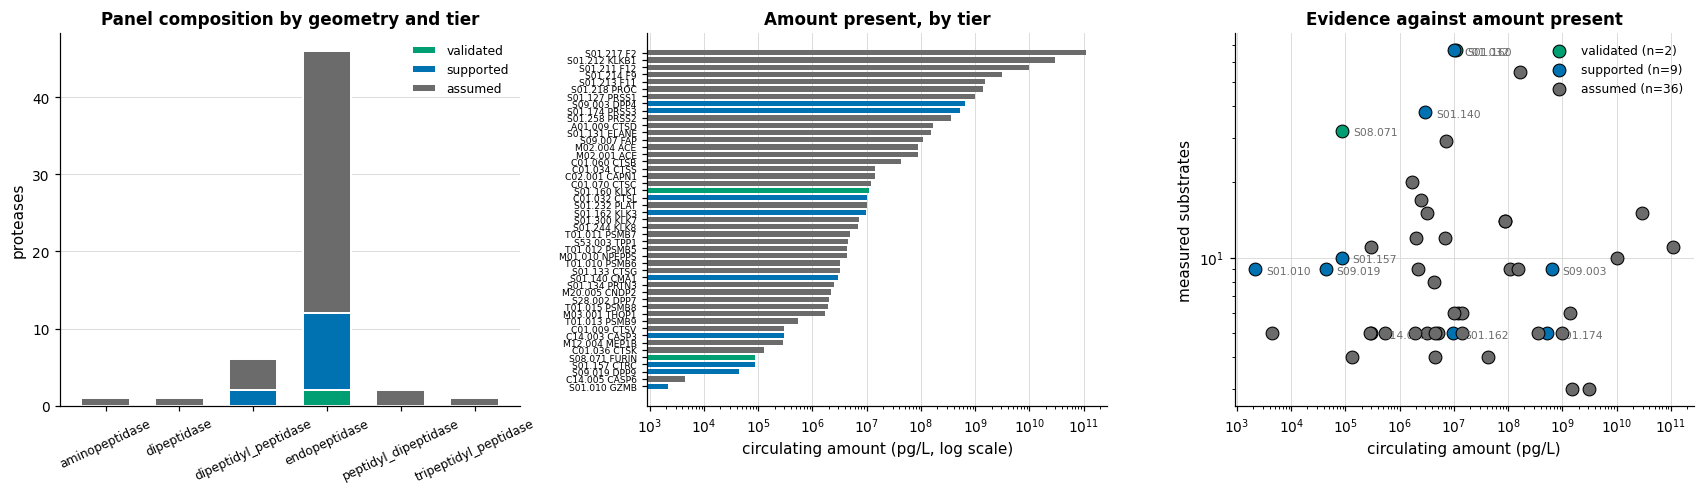

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15.6, 4.6))
tier_colour = {
    "validated": common.CATEGORICAL_COLORS[2],
    "supported": common.CATEGORICAL_COLORS[0],
    "assumed": common.NEUTRAL,
}

ax = axes[0]
composition = panel.groupby(["event_geometry", "validation_tier"]).size().unstack(fill_value=0)
bottom = np.zeros(len(composition))
for tier in ["validated", "supported", "assumed"]:
    if tier not in composition:
        continue
    ax.bar(composition.index, composition[tier], bottom=bottom, color=tier_colour[tier],
           label=tier, width=0.66, edgecolor="white", linewidth=1.3)
    bottom += composition[tier].to_numpy()
ax.set_ylabel("proteases")
ax.set_title("Panel composition by geometry and tier")
ax.tick_params(axis="x", rotation=25, labelsize=8)
ax.legend(fontsize=8)
ax.grid(axis="x", visible=False)

ax = axes[1]
with_abundance = panel.dropna(subset=["abundance_pg_per_l"]).sort_values("abundance_pg_per_l")
ax.barh(
    range(len(with_abundance)),
    with_abundance["abundance_pg_per_l"],
    color=[tier_colour[tier] for tier in with_abundance["validation_tier"]],
    height=0.72,
)
ax.set_yticks(range(len(with_abundance)))
ax.set_yticklabels(
    [f"{row.merops_code} {row.gene_name}" for row in with_abundance.itertuples()], fontsize=6
)
ax.set_xscale("log")
ax.set_xlabel("circulating amount (pg/L, log scale)")
ax.set_title("Amount present, by tier")
ax.grid(axis="y", visible=False)

ax = axes[2]
plotted = panel.dropna(subset=["abundance_pg_per_l"])
for tier, colour in tier_colour.items():
    subset = plotted[plotted["validation_tier"] == tier]
    if not len(subset):
        continue
    ax.scatter(
        subset["abundance_pg_per_l"], subset["n_substrates"],
        s=70, color=colour, edgecolor="black", linewidth=0.7, label=f"{tier} (n={len(subset)})",
    )
for _, row in plotted.query("validation_tier != 'assumed'").iterrows():
    ax.annotate(row["merops_code"], (row["abundance_pg_per_l"], row["n_substrates"]),
                textcoords="offset points", xytext=(7, -3), fontsize=7, color=common.NEUTRAL)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("circulating amount (pg/L)")
ax.set_ylabel("measured substrates")
ax.set_title("Evidence against amount present")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## The panel

One row per protease, with everything the time model needs and an explicit
record of what is absent. The three tiers define the sensitivity analysis the
`3_` and `4_` notebooks are expected to report: the full panel, the validated
and supported subset, and the validated subset alone.

In [9]:
columns = [
    "merops_code", "name", "gene_name", "ec_number", "uniprot_accession",
    "event_geometry", "geometry_source", "admissible_bonds_at_reference_length",
    "merops_cleavages", "n_substrates", "n_clusters", "median_subsites",
    "in_sample_rho_2_03", "ci_low", "ci_high", "test_rho_median",
    "fraction_positive_splits", "q_value", "verdict", "validation_tier",
    "ms_pg_per_l", "immunoassay_pg_per_l", "abundance_pg_per_l", "abundance_methods",
    "shares_measurements_with_n_codes", "has_geometry", "has_abundance", "evidence_is_own",
]
model_panel = panel[columns].sort_values(
    ["validation_tier", "n_substrates"], ascending=[True, False]
)
destination = common.save_result(model_panel, "2_07_model_panel.csv")
print(f"written: {destination.relative_to(common.ROOT)}")
print()
for tier in ["validated", "supported", "assumed"]:
    subset = model_panel.query("validation_tier == @tier")
    print(f"{tier:10s} {len(subset):3d} proteases | "
          f"geometry {int(subset['has_geometry'].sum())} | "
          f"abundance {int(subset['has_abundance'].sum())}")
model_panel.head(15)

written: assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/2_07_model_panel.csv

validated    2 proteases | geometry 2 | abundance 2
supported   12 proteases | geometry 12 | abundance 9
assumed     43 proteases | geometry 43 | abundance 36


,merops_code,name,gene_name,ec_number,uniprot_accession,event_geometry,geometry_source,admissible_bonds_at_reference_length,merops_cleavages,n_substrates,...,verdict,validation_tier,ms_pg_per_l,immunoassay_pg_per_l,abundance_pg_per_l,abundance_methods,shares_measurements_with_n_codes,has_geometry,has_abundance,evidence_is_own
2,S01.161,kallikrein-related peptidase 2,KLK2,3.4.21.35,P20151,endopeptidase,ec,16,66,67,...,not_supported,assumed,NaN,NaN,NaN,0,2,True,False,False
3,A01.009,cathepsin D,CTSD,3.4.23.5,P07339,endopeptidase,ec,16,923,55,...,not_supported,assumed,1.400000e+08,1.650000e+08,1.650000e+08,2,1,True,True,True
6,S01.300,kallikrein-related peptidase 7,KLK7,3.4.21.117,P49862,endopeptidase,ec,16,43,29,...,not_supported,assumed,7.300000e+06,NaN,7.300000e+06,1,1,True,True,True
7,M10.009,matrix metallopeptidase-12,MMP12,3.4.24.65,P39900,endopeptidase,ec,16,312,21,...,no_usable_holdout,assumed,NaN,NaN,NaN,0,1,True,False,True
8,M03.001,thimet oligopeptidase,THOP1,3.4.24.15,P52888,endopeptidase,ec,16,124,20,...,no_usable_holdout,assumed,1.700000e+06,NaN,1.700000e+06,1,1,True,True,True
9,S01.134,myeloblastin,PRTN3,3.4.21.76,P24158,endopeptidase,ec,16,55,17,...,no_usable_holdout,assumed,2.500000e+06,NaN,2.500000e+06,1,1,True,True,True
10,M03.006,mitochondrial intermediate peptidase,MIPEP,3.4.24.59,Q99797,endopeptidase,ec,16,32,15,...,no_usable_holdout,assumed,NaN,NaN,NaN,0,1,True,False,True
11,S01.133,cathepsin G,CTSG,3.4.21.20,P08311,endopeptidase,ec,16,465,15,...,no_usable_holdout,assumed,3.200000e+06,NaN,3.200000e+06,1,1,True,True,True
12,S01.212,plasma kallikrein,KLKB1,3.4.21.34,P03952,endopeptidase,ec,16,40,15,...,no_usable_holdout,assumed,1.200000e+10,2.900000e+10,2.900000e+10,2,1,True,True,True
13,M02.004,angiotensin-converting enzyme peptidase unit 2,ACE,3.4.15.1,P12821,peptidyl_dipeptidase,ec,1,13,14,...,no_usable_holdout,assumed,5.900000e+07,8.700000e+07,8.700000e+07,2,2,True,True,False


## Abundance against validation verdict

The hazard model multiplies a window score by how much of the enzyme circulates, so
the two quantities are used together and should be looked at together. The figure
below is the panel's circulating amount, coloured by what the held-out validation
concluded about that enzyme's matrix.

The question it answers is blunt: **is the part of the panel that carries most of
the hazard the part whose specificity was actually validated?** If the abundant
enzymes are the unvalidated ones, then a concentration-weighted result is dominated
by matrices nothing has checked, and every statement made with that weighting
inherits the problem.

panel proteases with an abundance estimate: 47 of 57

                   proteases     median         total  share_of_total
verdict                                                              
accepted                   2  5543500.0  1.108700e+07          0.0001
no_usable_holdout         41  6900000.0  1.581142e+11          0.9988
not_supported              4  8650000.0  1.853000e+08          0.0012

share of the panel's circulating amount held by validated proteases: 0.0070%


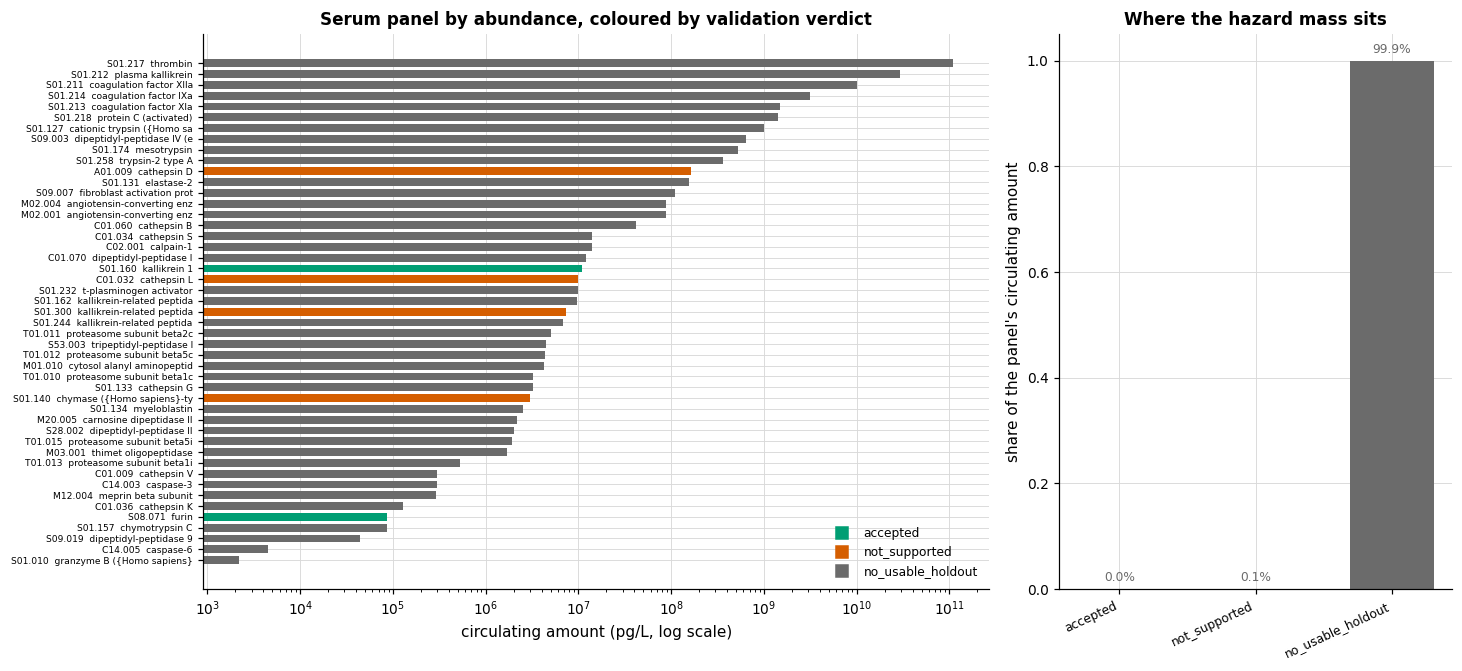

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/2_07_abundance_by_verdict.csv')

In [10]:
VERDICT_COLOURS = {
    "accepted": common.CATEGORICAL_COLORS[2],
    "not_supported": common.CATEGORICAL_COLORS[1],
    "no_usable_holdout": common.NEUTRAL,
    "insufficient_evidence": common.CATEGORICAL_COLORS[3],
}
VERDICT_ORDER = ["accepted", "not_supported", "no_usable_holdout", "insufficient_evidence"]

with_abundance = panel.dropna(subset=["abundance_pg_per_l"]).copy()
with_abundance["verdict"] = with_abundance["verdict"].fillna("insufficient_evidence")
print(f"panel proteases with an abundance estimate: {len(with_abundance)} of {len(panel)}")
print()
print(
    with_abundance.groupby("verdict")["abundance_pg_per_l"]
    .agg(proteases="size", median="median", total="sum")
    .assign(share_of_total=lambda f: f["total"] / f["total"].sum())
    .round(4)
    .to_string()
)

## The hazard is linear in abundance, so the share of total circulating amount is
## the share of the hazard each verdict class carries before any score is applied.
share_validated = (
    with_abundance.loc[with_abundance["verdict"] == "accepted", "abundance_pg_per_l"].sum()
    / with_abundance["abundance_pg_per_l"].sum()
)
print(f"\nshare of the panel's circulating amount held by validated proteases: {share_validated:.4%}")

fig, axes = plt.subplots(1, 2, figsize=(13.4, 6.2), gridspec_kw={"width_ratios": [2, 1]})

ax = axes[0]
ordered = with_abundance.sort_values("abundance_pg_per_l")
for position, row in enumerate(ordered.itertuples()):
    ax.barh(position, row.abundance_pg_per_l,
            color=VERDICT_COLOURS.get(row.verdict, common.NEUTRAL), height=0.72)
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels([f"{row.merops_code}  {str(row.name)[:26]}" for row in ordered.itertuples()], fontsize=6)
ax.set_xscale("log")
ax.set_xlabel("circulating amount (pg/L, log scale)")
ax.set_title("Serum panel by abundance, coloured by validation verdict")
handles = [
    plt.Line2D([], [], marker="s", linestyle="none", markersize=8, color=VERDICT_COLOURS[v], label=v)
    for v in VERDICT_ORDER if v in set(with_abundance["verdict"])
]
ax.legend(handles=handles, frameon=False, fontsize=8, loc="lower right")

ax = axes[1]
shares = (
    with_abundance.groupby("verdict")["abundance_pg_per_l"].sum()
    .reindex([v for v in VERDICT_ORDER if v in set(with_abundance["verdict"])])
)
shares = shares / shares.sum()
ax.bar(range(len(shares)), shares.to_numpy(),
       color=[VERDICT_COLOURS[v] for v in shares.index], width=0.62)
for position, value in enumerate(shares.to_numpy()):
    ax.text(position, value + 0.015, f"{value:.1%}", ha="center", fontsize=8, color=common.NEUTRAL)
ax.set_xticks(range(len(shares)))
ax.set_xticklabels(shares.index, rotation=25, ha="right", fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel("share of the panel's circulating amount")
ax.set_title("Where the hazard mass sits")

fig.tight_layout()
plt.show()

common.save_result(
    with_abundance.groupby("verdict")["abundance_pg_per_l"]
    .agg(proteases="size", median_pg_per_l="median", total_pg_per_l="sum")
    .reset_index(),
    "2_07_abundance_by_verdict.csv",
)